# Matemática Atuarial, Análise de Sobrevivência e Expectativa de Vida com Python

## Sumário:

- Variável aleatória T: tempo de vida futuro
- Análise de sobrevivência;
- Modelos de sobrevivência;
    - prob. sobrevivência;
    - prob. morte;
    - força de mortalidade;
- Introdução a Tábua de vida;
- Expectativa de vida:
    - de um recém-nascido;
    - de um indivíduo de 21 anos.

**1. Instalando o pacote de matemática atuarial em python 'acturialmath':**

In [36]:
%pip install actuarialmath

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**2. Importando as bibliotecas e pacotes necessários:**


In [24]:
# Bibliotecas fundamentais  
import pandas as pd
import numpy as np
import math
import matplotlib as mpl
import scipy as sp


In [25]:
# Pacotes sobre matemática atuarial
from actuarialmath import Survival
from actuarialmath import Life
from actuarialmath import Lifetime

### Primeiro modelo de sobrevivência: Força de Mortalidade *(mu)*

In [26]:
# Lista todos os métodos e atributos do pacote
atributos = dir(Survival)

# Itera sobre cada atributo e exibe detalhes
for atributo in atributos:
    print(f"Detalhes de {atributo}:")
    print(help(getattr(Survival, atributo)))
    print("\n" + "="*80 + "\n")

Detalhes de VARIANCE:
Help on int object:

class int(object)
 |  int([x]) -> integer
 |  int(x, base=10) -> integer
 |  
 |  Convert a number or string to an integer, or return 0 if no arguments
 |  are given.  If x is a number, return x.__int__().  For floating point
 |  numbers, this truncates towards zero.
 |  
 |  If x is not a number or if base is given, then x must be a string,
 |  bytes, or bytearray instance representing an integer literal in the
 |  given base.  The literal can be preceded by '+' or '-' and be surrounded
 |  by whitespace.  The base defaults to 10.  Valid bases are 0 and 2-36.
 |  Base 0 means to interpret the base from the string as an integer literal.
 |  >>> int('0b100', base=0)
 |  4
 |  
 |  Built-in subclasses:
 |      bool
 |  
 |  Methods defined here:
 |  
 |  __abs__(self, /)
 |      abs(self)
 |  
 |  __add__(self, value, /)
 |      Return self+value.
 |  
 |  __and__(self, value, /)
 |      Return self&value.
 |  
 |  __bool__(self, /)
 |      True

Help on int object:

class int(object)
 |  int([x]) -> integer
 |  int(x, base=10) -> integer
 |  
 |  Convert a number or string to an integer, or return 0 if no arguments
 |  are given.  If x is a number, return x.__int__().  For floating point
 |  numbers, this truncates towards zero.
 |  
 |  If x is not a number or if base is given, then x must be a string,
 |  bytes, or bytearray instance representing an integer literal in the
 |  given base.  The literal can be preceded by '+' or '-' and be surrounded
 |  by whitespace.  The base defaults to 10.  Valid bases are 0 and 2-36.
 |  Base 0 means to interpret the base from the string as an integer literal.
 |  >>> int('0b100', base=0)
 |  4
 |  
 |  Built-in subclasses:
 |      bool
 |  
 |  Methods defined here:
 |  
 |  __abs__(self, /)
 |      abs(self)
 |  
 |  __add__(self, value, /)
 |      Return self+value.
 |  
 |  __and__(self, value, /)
 |      Return self&value.
 |  
 |  __bool__(self, /)
 |      True if self else False
 |

In [27]:
print(dir(Survival))

['VARIANCE', 'WHOLE', '_MAXAGE', '_MINAGE', '_RADIX', '_TOL', '_VARIANCE', '_WHOLE', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_verbose', 'add_term', 'bernoulli', 'binomial', 'conditional_variance', 'covariance', 'd_x', 'derivative', 'f_x', 'integral', 'isclose', 'l_x', 'max_term', 'mixture', 'mu_x', 'p_x', 'portfolio_cdf', 'portfolio_percentile', 'q_x', 'quantiles_frame', 'set_interest', 'set_survival', 'solve', 'variance']


In [28]:
# Definindo a função de mortalidade mu
def mu(x, s=0):
    return 0. if (x+s) >= 90 else (0.9 / (90 - (x+s)))

# Criando o objeto de Survival
survival_model_mu = Survival().set_survival(mu=mu, minage=0, maxage=90)


### Segundo modelo de sobrevivência: Probabilidade de Sobrevivência *(S)*

In [29]:
# Definindo a função de sobrevivência S
def S(x):
    if x >= 90:
        return 0  # Garantindo que para idades >= 90 a sobrevivência é zero
    return math.exp(-survival_model_mu.integral(mu, 0, x))

print(S(89))


0.017425359290446692


### Terceiro modelo de sobrevivência: Probabilidade de Morte *(F)*

In [30]:
# Definindo a função de mortalidade F
def F(x):
    return 1 - S(x)

print(F(88))


0.9674831297852617


### Expectativa de Vida *(e_x)*

In [31]:
# Lista todos os métodos e atributos do pacote
atributos = dir(Lifetime)

# Itera sobre cada atributo e exibe detalhes
for atributo in atributos:
    print(f"Detalhes de {atributo}:")
    print(help(getattr(Lifetime, atributo)))
    print("\n" + "="*80 + "\n")

Detalhes de VARIANCE:
Help on int object:

class int(object)
 |  int([x]) -> integer
 |  int(x, base=10) -> integer
 |  
 |  Convert a number or string to an integer, or return 0 if no arguments
 |  are given.  If x is a number, return x.__int__().  For floating point
 |  numbers, this truncates towards zero.
 |  
 |  If x is not a number or if base is given, then x must be a string,
 |  bytes, or bytearray instance representing an integer literal in the
 |  given base.  The literal can be preceded by '+' or '-' and be surrounded
 |  by whitespace.  The base defaults to 10.  Valid bases are 0 and 2-36.
 |  Base 0 means to interpret the base from the string as an integer literal.
 |  >>> int('0b100', base=0)
 |  4
 |  
 |  Built-in subclasses:
 |      bool
 |  
 |  Methods defined here:
 |  
 |  __abs__(self, /)
 |      abs(self)
 |  
 |  __add__(self, value, /)
 |      Return self+value.
 |  
 |  __and__(self, value, /)
 |      Return self&value.
 |  
 |  __bool__(self, /)
 |      True

Help on int object:

class int(object)
 |  int([x]) -> integer
 |  int(x, base=10) -> integer
 |  
 |  Convert a number or string to an integer, or return 0 if no arguments
 |  are given.  If x is a number, return x.__int__().  For floating point
 |  numbers, this truncates towards zero.
 |  
 |  If x is not a number or if base is given, then x must be a string,
 |  bytes, or bytearray instance representing an integer literal in the
 |  given base.  The literal can be preceded by '+' or '-' and be surrounded
 |  by whitespace.  The base defaults to 10.  Valid bases are 0 and 2-36.
 |  Base 0 means to interpret the base from the string as an integer literal.
 |  >>> int('0b100', base=0)
 |  4
 |  
 |  Built-in subclasses:
 |      bool
 |  
 |  Methods defined here:
 |  
 |  __abs__(self, /)
 |      abs(self)
 |  
 |  __add__(self, value, /)
 |      Return self+value.
 |  
 |  __and__(self, value, /)
 |      Return self&value.
 |  
 |  __bool__(self, /)
 |      True if self else False
 |

**Cálculo da expectativa de vida de um recém-nascido:**

In [37]:
def mu(x, s=0):
    return 0. if (x+s) >= 90 else (0.9 / (90 - (x+s)))

def e_x(x):
    print(f"Calculando e_x para idade x={x}")
    if x >= 90:
        return 0
    return Lifetime().set_survival(mu=mu).e_x(x, t=90, curtate=False)

e = e_x(0)

print(e)


Calculando e_x para idade x=0
47.368421052631575


**Cálculo da expectativa de vida de um indivíduo de 21 anos de idade:**

In [46]:
def mu(x, s=0):
    return 0. if (x+s) >= 90 else (0.9 / (90 - (x+s)))

e = Lifetime().set_survival(mu=mu)

print(e.e_x(21, t=90, curtate=False))


36.3188900483936


In [ ]:
idade = np.arange(0, 90)

# Criando um DataFrame para armazenar os resultados
df_survival = pd.DataFrame({'idade': idade})

In [38]:
df_survival['mu(x)'] = df_survival['idade'].apply(mu)
print(df_survival)

df_survival['S(x)'] = df_survival['idade'].apply(S)
print(df_survival)

df_survival['F(x)'] = df_survival['idade'].apply(F)
print(df_survival)

df_survival['e_x'] = df_survival['idade'].apply(e_x)
print(df_survival)


    idade     mu(x)      S(x)      F(x)
0       0  0.010000  1.000000  0.000000
1       1  0.010112  0.989994  0.010006
2       2  0.010227  0.979978  0.020022
3       3  0.010345  0.969949  0.030051
4       4  0.010465  0.959910  0.040090
..    ...       ...       ...       ...
85     85  0.180000  0.074175  0.925825
86     86  0.225000  0.060679  0.939321
87     87  0.300000  0.046837  0.953163
88     88  0.450000  0.032517  0.967483
89     89  0.900000  0.017425  0.982575

[90 rows x 4 columns]
    idade     mu(x)      S(x)      F(x)
0       0  0.010000  1.000000  0.000000
1       1  0.010112  0.989994  0.010006
2       2  0.010227  0.979978  0.020022
3       3  0.010345  0.969949  0.030051
4       4  0.010465  0.959910  0.040090
..    ...       ...       ...       ...
85     85  0.180000  0.074175  0.925825
86     86  0.225000  0.060679  0.939321
87     87  0.300000  0.046837  0.953163
88     88  0.450000  0.032517  0.967483
89     89  0.900000  0.017425  0.982575

[90 rows x 4 col

In [39]:
print(df_survival['e_x'])

0     47.368421
1     46.842958
2     46.316402
3     45.790385
4     45.263876
        ...    
85     2.683302
86     2.243918
87     1.703916
88     1.288295
89     1.073711
Name: e_x, Length: 90, dtype: float64


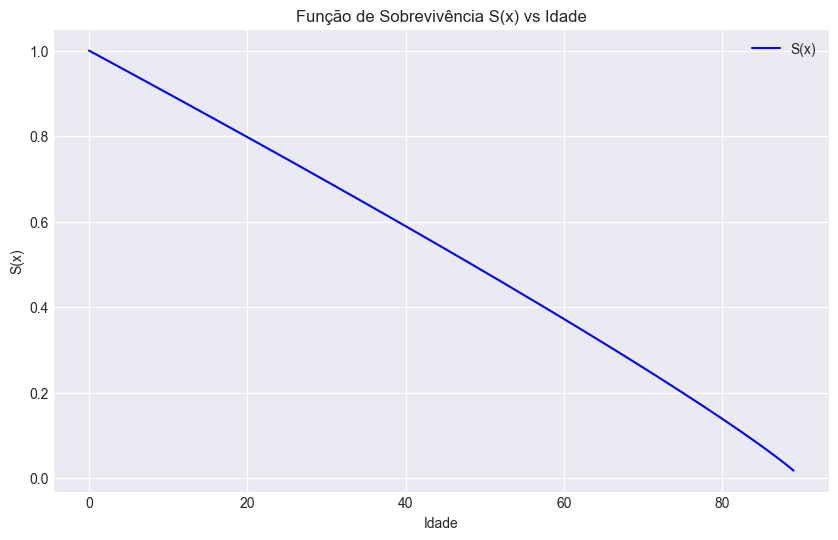

In [41]:
import matplotlib.pyplot as plt

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_survival['idade'], df_survival['S(x)'], label='S(x)', color='blue')

# Adicionando título e rótulos aos eixos
plt.title('Função de Sobrevivência S(x) vs Idade')
plt.xlabel('Idade')
plt.ylabel('S(x)')

# Adicionando uma grade
plt.grid(True)

# Adicionando uma legenda
plt.legend()

# Exibindo o gráfico
plt.show()

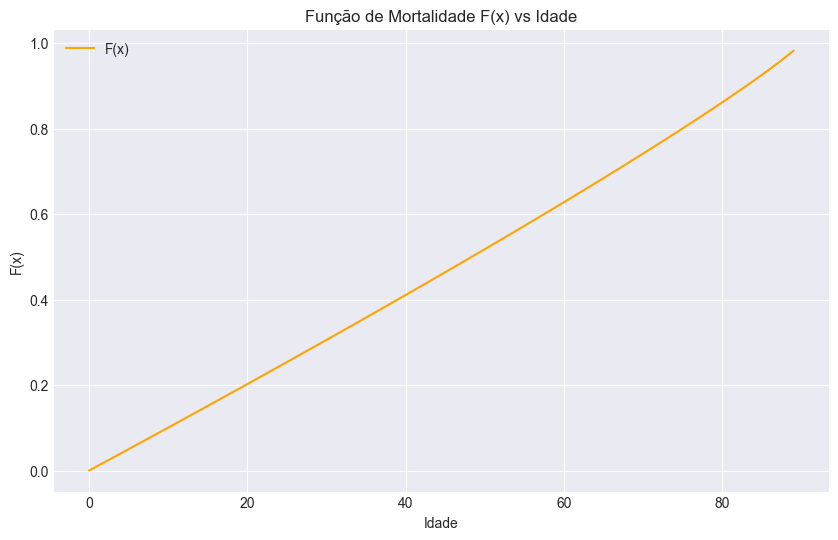

In [42]:
# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_survival['idade'], df_survival['F(x)'], label='F(x)', color='orange')

# Adicionando título e rótulos aos eixos
plt.title('Função de Mortalidade F(x) vs Idade')
plt.xlabel('Idade')
plt.ylabel('F(x)')

# Adicionando uma grade
plt.grid(True)

# Adicionando uma legenda
plt.legend()

# Exibindo o gráfico
plt.show()

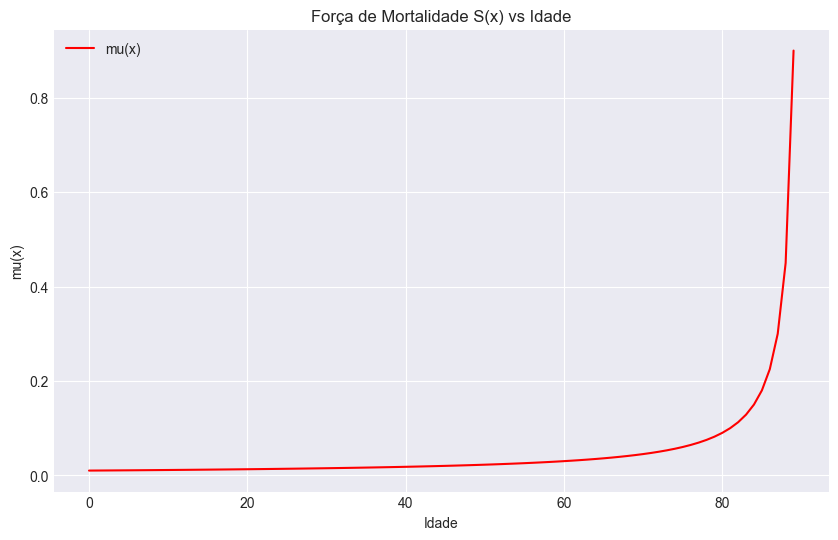

In [43]:
# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_survival['idade'], df_survival['mu(x)'], label='mu(x)', color='red')

# Adicionando título e rótulos aos eixos
plt.title('Força de Mortalidade S(x) vs Idade')
plt.xlabel('Idade')
plt.ylabel('mu(x)')

# Adicionando uma grade
plt.grid(True)

# Adicionando uma legenda
plt.legend()

# Exibindo o gráfico
plt.show()

Correlação de Pearson:
          mu(x)      S(x)      F(x)       e_x
mu(x)  1.000000 -0.513367  0.513367 -0.490316
S(x)  -0.513367  1.000000 -1.000000  0.999347
F(x)   0.513367 -1.000000  1.000000 -0.999347
e_x   -0.490316  0.999347 -0.999347  1.000000


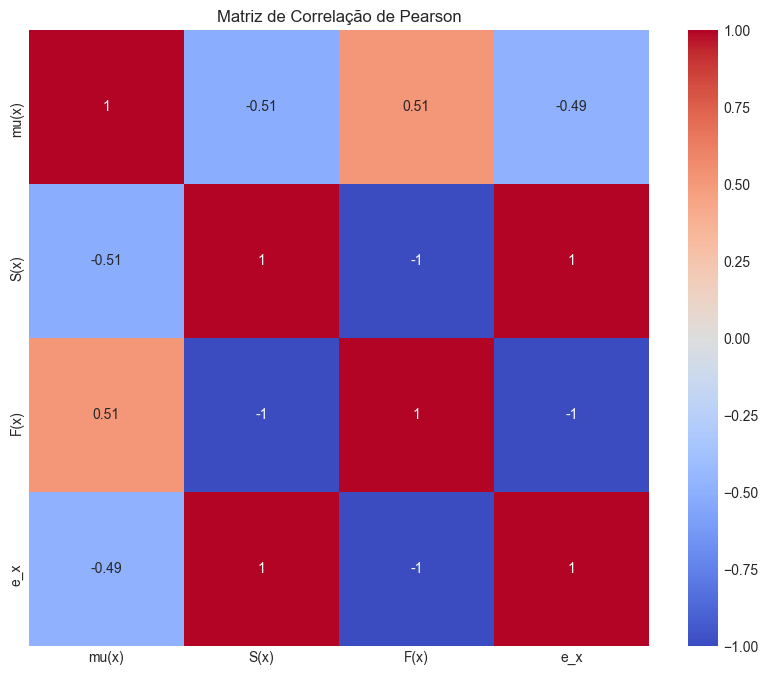

In [45]:
# Calculando a correlação de Pearson
correlation_matrix = df_survival[['mu(x)', 'S(x)', 'F(x)', 'e_x']].corr()
print("Correlação de Pearson:")
print(correlation_matrix)

# Visualizando graficamente a matriz de correlação
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Pearson')
plt.show()